In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('datasets\\mall_customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
df.shape

(200, 5)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


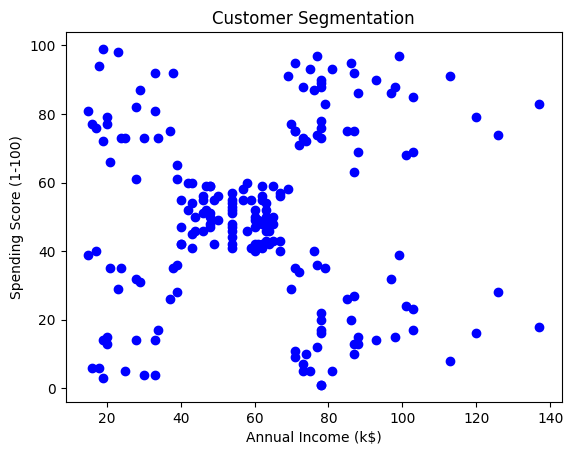

In [4]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], color='blue')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation')
plt.show()

In [5]:
df['Genre'].value_counts()

Genre
Female    112
Male       88
Name: count, dtype: int64

In [6]:
df = pd.get_dummies(df, columns=['Genre'], drop_first=True)
df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,1,19,15,39,True
1,2,21,15,81,True
2,3,20,16,6,False
3,4,23,16,77,False
4,5,31,17,40,False


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
scaler = StandardScaler()

In [14]:
X_scaled = scaler.fit_transform(X)
k_range = range(1, 15)
km = KMeans(n_clusters=3, random_state=42, n_init='auto')
km.fit(X_scaled)
print(km.labels_)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1
 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0
 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]


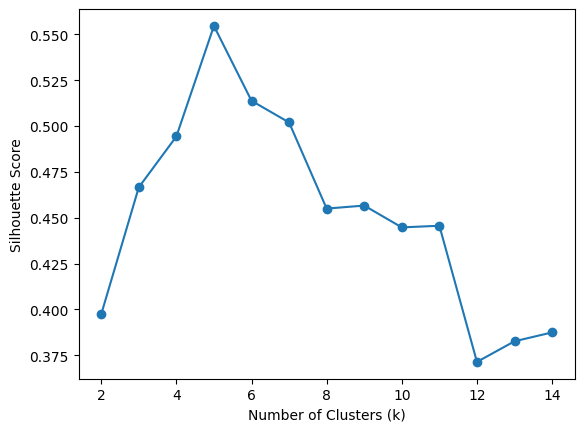

In [17]:
silhouette_scores = []
from sklearn.metrics import silhouette_score
k_range = range(2, 15)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled,km.labels_))
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

In [19]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_scaled)
labels = kmeans.predict(X_scaled)
df['Clusters'] = labels

In [20]:
df['Clusters'].value_counts()

Clusters
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

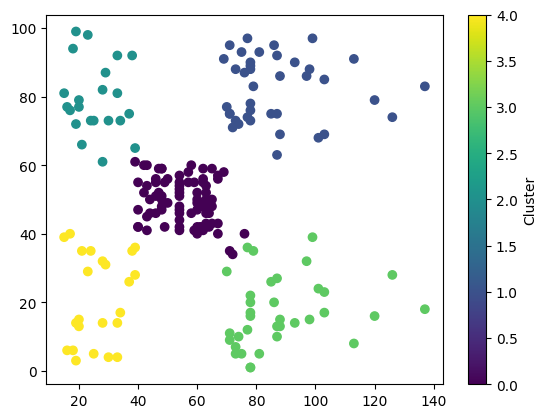

In [25]:
clusters = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Clusters'], cmap = 'viridis')
plt.colorbar(label = 'Cluster')
plt.show()

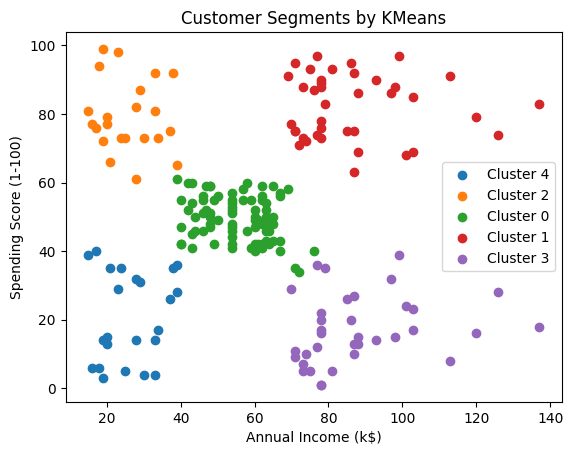

In [26]:
for cluster in df['Clusters'].unique():
    subset = df[df['Clusters'] == cluster]
    plt.scatter(
        subset['Annual Income (k$)'],
        subset['Spending Score (1-100)'],
        label=f'Cluster {cluster}'
    )

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments by KMeans')
plt.legend()
plt.show()


In [28]:
profiles = df.groupby('Clusters')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
profiles

,Age,Annual Income (k$),Spending Score (1-100)
Clusters,,,
0,42.7,55.3,49.5
1,32.7,86.5,82.1
2,25.3,25.7,79.4
3,41.1,88.2,17.1
4,45.2,26.3,20.9


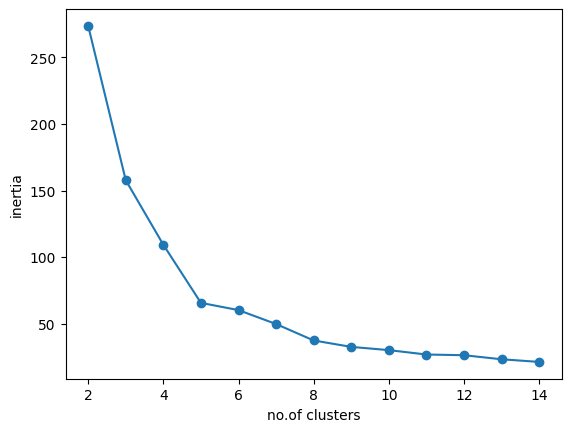

In [34]:
inertias = []
k_range = range(2, 15)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
plt.plot(k_range, inertias, marker = 'o')
plt.xlabel("no.of clusters")
plt.ylabel("inertia")
plt.show()

Clustering a dataset with more than one feature

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('datasets\\data_ecommerce_customer_churn.csv')
df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


In [4]:
features = [
    'Tenure',
    'WarehouseToHome',
    'NumberOfDeviceRegistered',
    'SatisfactionScore',
    'NumberOfAddress',
    'DaySinceLastOrder',
    'CashbackAmount'
]

In [6]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(df[features])

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

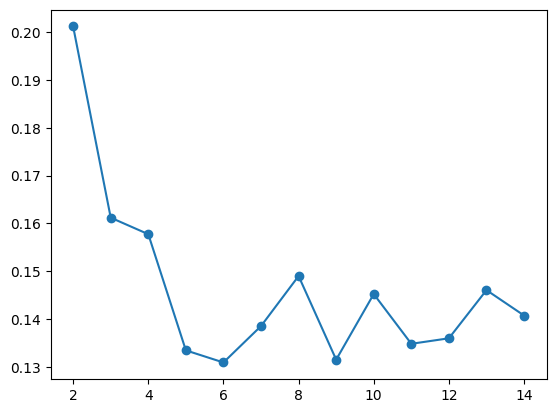

In [8]:
silhouette_scores = []
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
k_range = range(2,15)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
plt.plot(k_range, silhouette_scores, marker = 'o')
plt.show()

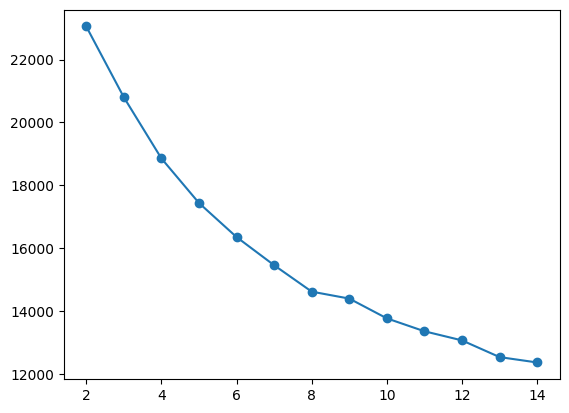

In [9]:
inertias = []
for k in range(2,15):
    kmeans = KMeans(n_clusters=k, random_state= 42, n_init='auto')
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
plt.plot(k_range, inertias, marker = 'o')
plt.show()

In [13]:
best = max(silhouette_scores)
for i in range(2, 15):
    if best == silhouette_scores[i-2]:
        print(f"{i}")

2


Masai Assignment

In [15]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import io

# Inline the data
raw_data = """CustomerID,Annual_Income,Spending_Score,Age
1,15,39,25
2,15,81,35
3,16,6,43
4,16,77,52
5,17,40,35
6,17,76,43
7,70,10,36
8,71,35,55
9,72,5,41
10,87,92,32
11,88,97,30
12,137,18,47"""

def find_best_k_and_summarize(raw_data):

    # Step 1: Load data
    df = pd.read_csv(io.StringIO(raw_data))

    # Step 2: Select features and scale
    X = df[['Annual_Income', 'Spending_Score']]

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)

    # Step 3: Test K = 2..6
    k_range = range(2, 7)

    silhouette_scores = []

    for k in k_range:

        km = KMeans(
            n_clusters=k,
            random_state=42,
            n_init='auto'
        )

        labels = km.fit_predict(X_scaled)

        score = silhouette_score(X_scaled, labels)

        silhouette_scores.append(score)

        print(f"K = {k}, Silhouette Score = {score:.4f}")

    # Step 4: Find best K
    best_score = max(silhouette_scores)

    best_k = k_range[silhouette_scores.index(best_score)]

    print(f"\nBest K = {best_k}")

    # Final model
    kmeans = KMeans(
        n_clusters=best_k,
        random_state=42,
        n_init='auto'
    )

    df['Cluster'] = kmeans.fit_predict(X_scaled)

    # Step 5: Cluster summary
    cluster_summary = df.groupby('Cluster')[
        ['Annual_Income', 'Spending_Score']
    ].mean()

    print("\nCluster Summary:\n")

    print(cluster_summary)


if __name__ == "__main__":
    find_best_k_and_summarize(raw_data)

K = 2, Silhouette Score = 0.3750
K = 3, Silhouette Score = 0.4165
K = 4, Silhouette Score = 0.6353
K = 5, Silhouette Score = 0.6544
K = 6, Silhouette Score = 0.6796

Best K = 6

Cluster Summary:

         Annual_Income  Spending_Score
Cluster                               
0                 16.0       39.500000
1                 87.5       94.500000
2                 16.0       78.000000
3                137.0       18.000000
4                 71.0       16.666667
5                 16.0        6.000000


In [16]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import io

# Inline the data
raw_data = """CustomerID,Annual_Income,Spending_Score,Age
1,15,39,25
2,15,81,35
3,16,6,43
4,16,77,52
5,17,40,35
6,17,76,43
7,70,10,36
8,71,35,55
9,72,5,41
10,87,92,32
11,88,97,30
12,137,18,47"""

def find_best_k_and_summarize(raw_data):

    # Step 1: Load data
    df = pd.read_csv(io.StringIO(raw_data))

    # Step 2: Select features
    X = df[['Annual_Income', 'Spending_Score', 'Age']]

    # Scale the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Step 3: Test K = 2 to 6
    best_k = None
    best_score = -1

    print("Silhouette Scores:\n")

    for k in range(2, 7):

        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init='auto'
        )

        labels = kmeans.fit_predict(X_scaled)

        score = silhouette_score(X_scaled, labels)

        print(f"K = {k}, Silhouette Score = {score:.4f}")

        if score > best_score:
            best_score = score
            best_k = k

    # Step 4: Fit final model with best K
    print(f"\nBest K selected: {best_k}")

    final_kmeans = KMeans(
        n_clusters=best_k,
        random_state=42,
        n_init='auto'
    )

    df['Cluster'] = final_kmeans.fit_predict(X_scaled)

    # Step 5: Cluster summary
    cluster_summary = df.groupby('Cluster')[
        ['Annual_Income', 'Spending_Score', 'Age']
    ].mean()

    print("\nCluster Summary:\n")
    print(cluster_summary)


if __name__ == "__main__":
    find_best_k_and_summarize(raw_data)

Silhouette Scores:

K = 2, Silhouette Score = 0.2936
K = 3, Silhouette Score = 0.2049
K = 4, Silhouette Score = 0.3387
K = 5, Silhouette Score = 0.3151
K = 6, Silhouette Score = 0.2875

Best K selected: 4

Cluster Summary:

         Annual_Income  Spending_Score        Age
Cluster                                          
0            29.500000       23.750000  34.750000
1            93.333333       19.333333  47.666667
2            16.000000       78.000000  43.333333
3            87.500000       94.500000  31.000000


In [4]:
import pandas as pd
df = pd.read_csv('datasets\\churnguard_data.csv')
print(f"The shape of dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"The first five records of the dataset:\n {df.head()}")
print(f"The information from dataset is (column names and datatypes)\n {df.info}")
print(f"The count of missing values in each column is:\n {df.isnull().sum()}")
print(f"The no.of duplicate rows is {df.duplicated().sum()}")
print(f"The value counts of Churn Column is\n {df['Churn'].value_counts()}")
print(f"The unique values in Contract column is\n {df['Contract'].unique()}")

The shape of dataset: 1030 rows, 12 columns
The first five records of the dataset:
   customerID  gender  SeniorCitizen  tenure PhoneService InternetService  \
0  CUST-0032    Male              0    21.0          YES     Fiber optic   
1  CUST-0110    Male              0    55.0          YES     Fiber optic   
2  CUST-0137  Female              1    46.0          Yes     Fiber optic   
3  CUST-0089  Female              1    63.0          Yes     Fiber optic   
4  CUST-0919  Female              0     8.0          Yes             DSl   

         Contract PaperlessBilling     PaymentMethod  MonthlyCharges  \
0  Month-to-month               No     Credit card             29.73   
1        Two year              Yes     Bank transfer           46.32   
2  Month-to-month               No    Mailed check             87.06   
3  Month-to-month              YES      Mailed check           56.97   
4  month to month               No  Electronic check           39.69   

  TotalCharges Churn  
0  

In [41]:
import pandas as pd
df = pd.read_csv('datasets\\churnguard_data.csv')
df = df.drop(columns='customerID')
df.drop_duplicates(inplace=True)
df['gender'] = df['gender'].str.strip()
df['PaymentMethod'] = df['PaymentMethod'].str.strip()
cols = ['Churn', 'PhoneService', 'PaperlessBilling']
for col in cols:
    df[col] = df[col].str.strip().str.title()
df['Contract'] = df['Contract'].map({'Month-to-month':'Month-to-month','month-to-month': 'Month-to-month',
                                     'month to month': 'Month-to-month', 'Monthly':'Month-to-month',
                                     'One year': 'One year', '1 year': 'One year', 'one year':'One year'
                                     ,'Two year': 'Two year', '2 year':'Two year','Two Year': 'Two year',
                                     'One Year': 'One year', 'two year': 'Two year'})
df['InternetService'] = df['InternetService'].map({'Fiber optic':'Fiber optic','DSL':'DSL', 'No':'No'
                                                   ,'Fibre optic': 'Fiber optic','fiber optic':'Fiber optic',
                                                   'dsl':'DSL', 'DSl':'DSL','FiberOptic': 'Fiber optic', 'Dsl':'DSL','NO':'No','no':'No' })
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df[df['tenure'] > 0]
df = df[(df['MonthlyCharges'] >= 10) & (df['MonthlyCharges'] <= 200)]
cols = ['MonthlyCharges', 'TotalCharges','tenure']
for col in cols:
    df[col] = df[col].fillna(df[col].mean())
df['InternetService'] = df['InternetService'].fillna(df['InternetService'].mode()[0])
print(f"The shape of cleaned data is {df.shape[0]} rows and {df.shape[1]} columns")
print(f"Missing value counts after cleaning:\n{df.isnull().sum()}")

The shape of cleaned data is 867 rows and 11 columns
Missing value counts after cleaning:
gender              0
SeniorCitizen       0
tenure              0
PhoneService        0
InternetService     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})
categorical_cols = [
    "gender",
    "PhoneService",
    "InternetService",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
X = df.drop('Churn', axis = 1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:")
print(accuracy)
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Stay", "Churn"]
    )
)

Accuracy Score:
0.7011494252873564

Classification Report:
              precision    recall  f1-score   support

        Stay       0.75      0.85      0.80       122
       Churn       0.50      0.35      0.41        52

    accuracy                           0.70       174
   macro avg       0.63      0.60      0.60       174
weighted avg       0.68      0.70      0.68       174



In [ ]:
contract_encode = {
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2
}

df["Contract"] = df["Contract"].map(contract_encode)

features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "SeniorCitizen",
    "Contract"
]

X = df[features]
y = df["Churn"]

model = LogisticRegression(max_iter=1000)

model.fit(X, y)

tenure = int(input("Enter tenure (months): "))
monthly_charges = float(input("Enter Monthly Charges: "))
total_charges = float(input("Enter Total Charges: "))
senior_citizen = int(input("Senior Citizen? (1 = Yes, 0 = No): "))
contract = int(
    input(
        "Contract type (0 = Month-to-month, 1 = One year, 2 = Two year): "
    )
)

user_data = pd.DataFrame([{
    "tenure": tenure,
    "MonthlyCharges": monthly_charges,
    "TotalCharges": total_charges,
    "SeniorCitizen": senior_citizen,
    "Contract": contract
}])

prediction = model.predict(user_data)[0]
if prediction == 1:
    print("Prediction: This customer is likely to CHURN.")
else:
    print("Prediction: This customer is likely to STAY.")

KeyError: "['Contract'] not in index"